# Análisis exploratorio — RAVDESS (habla emocional)

**Objetivo:** caracterizar el subconjunto de *habla* de RAVDESS (1440 clips, 24 actores, 8 emociones)
antes de entrenar un clasificador de emociones.

Los datos se consumen desde **Supabase** (tabla `ravdess_clips` + bucket `ravdess-audio`); los `.wav` se
descargan bajo demanda a una caché local desechable. Las figuras se guardan en `latex/figures/` y las cifras clave
en `latex/resultados_eda.tex` para que el reporte y la presentación no se desincronicen.

In [1]:
import sys, json
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import librosa, librosa.display
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from ravdess_data import load_metadata, ensure_audio, EMOTIONS_ES
from features import clip_descriptors, rms_envelope, SR, TOP_DB, FRAME_LENGTH, HOP_LENGTH, ENV_SECONDS

FIG = ROOT / "latex" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
DATA = ROOT / "data"; DATA.mkdir(exist_ok=True)

# Paleta categórica validada (8 slots, orden fijo) y estilo sobrio
ORDER = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]
ORDER_ES = [EMOTIONS_ES[e] for e in ORDER]
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
EMO_COLOR = dict(zip(ORDER_ES, PALETTE))
GENDER_COLOR = {"hombre": "#2a78d6", "mujer": "#eb6834"}
INT_COLOR = {"normal": "#86b6ef", "fuerte": "#1c5cab"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight", "font.size": 10,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "xtick.color": INK2, "ytick.color": INK2,
    "legend.frameon": False,
})
def save(fig, name):
    fig.savefig(FIG / f"{name}.pdf"); fig.savefig(FIG / f"{name}.png")

## 1. Carga de metadatos desde Supabase

In [2]:
df = load_metadata()
df["emocion"] = pd.Categorical(df["emotion"].map(EMOTIONS_ES), ORDER_ES, ordered=True)
df["genero"] = df["gender"].map({"male": "hombre", "female": "mujer"})
df["intensidad"] = df["intensity"].map({"normal": "normal", "strong": "fuerte"})
print(df.shape)
df.head()

(1440, 18)


,filename,storage_path,actor,gender,emotion_code,emotion,intensity,statement,repetition,size_bytes,sample_rate,channels,duration_s,created_at,emotion_es,emocion,genero,intensidad
0,03-01-01-01-01-01-01.wav,Actor_01/03-01-01-01-01-01-01.wav,1,male,1,neutral,normal,Kids are talking by the door,1,375720,48000,1,3.3033,2026-10-02T20:52:26.812651+00:00,neutral,neutral,hombre,normal
1,03-01-01-01-01-01-02.wav,Actor_02/03-01-01-01-01-01-02.wav,2,female,1,neutral,normal,Kids are talking by the door,1,410114,48000,1,3.6370,2026-10-02T20:52:26.812651+00:00,neutral,neutral,mujer,normal
2,03-01-01-01-01-01-03.wav,Actor_03/03-01-01-01-01-01-03.wav,3,male,1,neutral,normal,Kids are talking by the door,1,379588,48000,1,3.4368,2026-10-02T20:52:26.812651+00:00,neutral,neutral,hombre,normal
3,03-01-01-01-01-01-04.wav,Actor_04/03-01-01-01-01-01-04.wav,4,female,1,neutral,normal,Kids are talking by the door,1,374522,48000,1,3.3033,2026-10-02T20:52:26.812651+00:00,neutral,neutral,mujer,normal
4,03-01-01-01-01-01-05.wav,Actor_05/03-01-01-01-01-01-05.wav,5,male,1,neutral,normal,Kids are talking by the door,1,395284,48000,1,3.6036,2026-10-02T20:52:26.812651+00:00,neutral,neutral,hombre,normal


In [3]:
calidad = {
    "filas": len(df),
    "duplicados_filename": int(df["filename"].duplicated().sum()),
    "nulos": int(df.isna().sum().sum()),
    "frecuencias_muestreo": df["sample_rate"].value_counts().to_dict(),
    "canales": df["channels"].value_counts().to_dict(),
    "clips_estereo": df.loc[df["channels"] == 2, "filename"].tolist(),
    "tamano_total_mb": round(df["size_bytes"].sum() / 1e6, 1),
}
calidad

{'filas': 1440,
 'duplicados_filename': 0,
 'nulos': 0,
 'frecuencias_muestreo': {48000: 1440},
 'canales': {1: 1435, 2: 5},
 'clips_estereo': ['03-01-02-01-01-02-01.wav',
  '03-01-02-01-02-02-05.wav',
  '03-01-03-01-02-01-20.wav',
  '03-01-06-01-01-02-20.wav',
  '03-01-08-01-02-02-01.wav'],
 'tamano_total_mb': np.float64(590.3)}

## 2. Composición del dataset

El nombre de cada archivo codifica `modalidad-canal-emoción-intensidad-frase-repetición-actor`.
El diseño es factorial: cada actor graba 2 frases × 2 repeticiones × (7 emociones × 2 intensidades + neutral × 1 intensidad) = 60 clips.

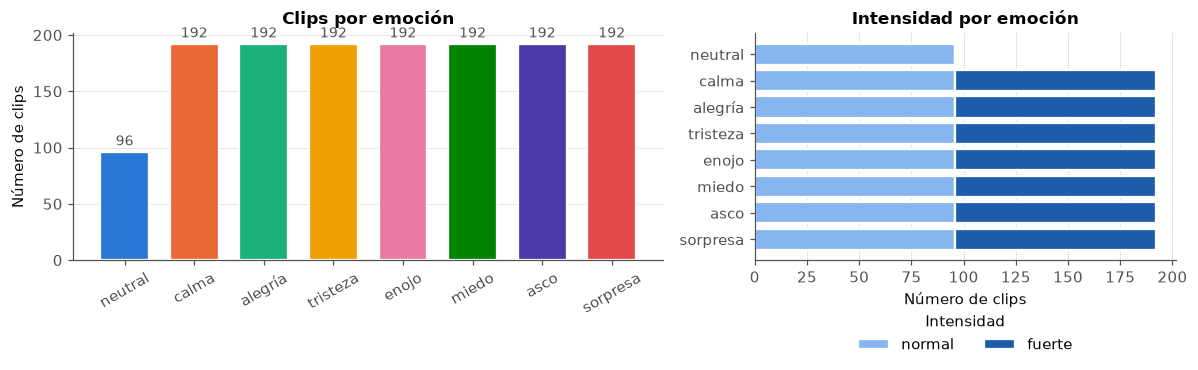

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.4, 1]})
cnt = df["emocion"].value_counts().reindex(ORDER_ES)
ax = axes[0]
ax.bar(cnt.index, cnt.values, color=[EMO_COLOR[e] for e in cnt.index], width=0.7, edgecolor="white", linewidth=1.5)
for i, v in enumerate(cnt.values):
    ax.text(i, v + 3, str(v), ha="center", va="bottom", color=INK2, fontsize=9)
ax.set_title("Clips por emoción"); ax.set_ylabel("Número de clips"); ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", rotation=30)

ct = pd.crosstab(df["emocion"], df["intensidad"]).reindex(ORDER_ES)[["normal", "fuerte"]]
ax = axes[1]
ax.barh(ct.index, ct["normal"], color=INT_COLOR["normal"], label="normal", edgecolor="white", linewidth=1.5)
ax.barh(ct.index, ct["fuerte"], left=ct["normal"], color=INT_COLOR["fuerte"], label="fuerte", edgecolor="white", linewidth=1.5)
ax.invert_yaxis(); ax.set_title("Intensidad por emoción"); ax.set_xlabel("Número de clips"); ax.grid(axis="y", visible=False)
ax.legend(title="Intensidad", loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
fig.tight_layout(); save(fig, "distribucion_emociones")

In [5]:
tabla_diseno = pd.crosstab(df["actor"], df["emocion"])
print("Clips por actor:", df.groupby("actor").size().unique(), "| hombres:", (df.drop_duplicates("actor")["genero"] == "hombre").sum(),
      "| mujeres:", (df.drop_duplicates("actor")["genero"] == "mujer").sum())
pd.crosstab(df["genero"], df["emocion"])

Clips por actor: [60] | hombres: 12 | mujeres: 12


emocion,neutral,calma,alegría,tristeza,enojo,miedo,asco,sorpresa
genero,,,,,,,,
hombre,48,96,96,96,96,96,96,96
mujer,48,96,96,96,96,96,96,96


## 3. Longitud de cuadro (*frame length*) y salto (*hop length*)
Se extraen tres familias de características con [librosa](https://librosa.org/doc/latest/index.html):
**MFCC** (coeficientes cepstrales en frecuencia mel), **ZCR** (tasa de cruces por cero) y **RMS** (energía cuadrática media).
Todas se calculan cuadro a cuadro, así que antes hay que fijar dos parámetros:

- **frame length**: muestras por cuadro. Cuadros largos dan mejor resolución en frecuencia pero suavizan los cambios rápidos.
- **hop length**: muestras que avanza la ventana entre cuadros consecutivos. Controla la resolución temporal y el traslape.

Se comparan varias combinaciones (con hop = frame/4, es decir, 75 % de traslape) sobre un mismo clip.

Elegido: frame_length=2048 (92.9 ms), hop_length=512 (23.2 ms)


,frame_length,hop_length,ventana (ms),salto (ms),cuadros en 2.5 s
0,512,128,23.2,5.8,431
1,1024,256,46.4,11.6,216
2,2048,512,92.9,23.2,108
3,4096,1024,185.8,46.4,54


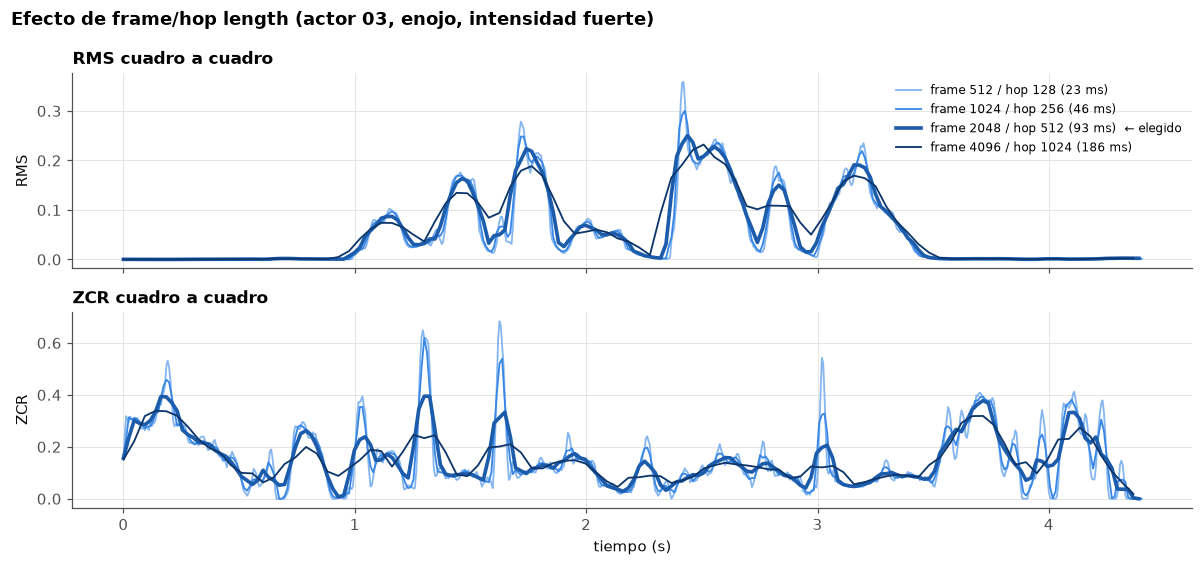

In [6]:
df = ensure_audio(df, workers=16)
FRAMES = [512, 1024, 2048, 4096]
RAMP = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]   # rampa ordinal: más oscuro = cuadro más largo
fh_clip = df[(df.actor == 3) & (df.emotion == "angry") & (df.intensity == "strong") &
             df.statement.str.startswith("Kids") & (df.repetition == 1)].iloc[0]
y_fh, _ = librosa.load(fh_clip.path, sr=SR)
tabla_fh = pd.DataFrame([{"frame_length": f, "hop_length": f // 4, "ventana (ms)": 1000 * f / SR,
                          "salto (ms)": 1000 * (f // 4) / SR, "cuadros en 2.5 s": 1 + int(SR * 2.5) // (f // 4)} for f in FRAMES])
fig, axes = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True)
for f, c in zip(FRAMES, RAMP):
    hop = f // 4
    rms = librosa.feature.rms(y=y_fh, frame_length=f, hop_length=hop)[0]
    zcr = librosa.feature.zero_crossing_rate(y_fh, frame_length=f, hop_length=hop)[0]
    t = librosa.frames_to_time(np.arange(len(rms)), sr=SR, hop_length=hop)
    lw = 2.4 if f == FRAME_LENGTH else 1.2
    lab = f"frame {f} / hop {hop} ({1000 * f / SR:.0f} ms)" + ("  ← elegido" if f == FRAME_LENGTH else "")
    axes[0].plot(t, rms, color=c, lw=lw, label=lab)
    axes[1].plot(t, zcr, color=c, lw=lw, label=lab)
axes[0].set_title("RMS cuadro a cuadro", loc="left"); axes[0].set_ylabel("RMS")
axes[1].set_title("ZCR cuadro a cuadro", loc="left"); axes[1].set_ylabel("ZCR"); axes[1].set_xlabel("tiempo (s)")
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Efecto de frame/hop length (actor 03, enojo, intensidad fuerte)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "frame_hop_length")
print(f"Elegido: frame_length={FRAME_LENGTH} ({1000*FRAME_LENGTH/SR:.1f} ms), hop_length={HOP_LENGTH} ({1000*HOP_LENGTH/SR:.1f} ms)")
tabla_fh.round(1)

## 4. Extracción de descriptores acústicos
Se descarga el audio desde Supabase y se calculan, sobre la señal sin silencios (top_db=30): RMS, ZCR, centroide y roll-off espectral, F0 (pYIN) y 20 MFCC medios.

In [7]:
with ProcessPoolExecutor() as ex:
    feats = list(ex.map(clip_descriptors, df["path"], chunksize=8))
feat = pd.DataFrame(feats).astype(float)
data = pd.concat([df.reset_index(drop=True), feat], axis=1)
data.drop(columns=["path"]).to_csv(DATA / "ravdess_descriptores.csv", index=False)
data[["dur_total", "dur_voz", "sil_inicio", "sil_final", "rms_media", "zcr_media", "centroide_media", "f0_media"]].describe().round(3)

,dur_total,dur_voz,sil_inicio,sil_final,rms_media,zcr_media,centroide_media,f0_media
count,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1427.000
mean,3.701,1.871,0.937,0.893,0.021,0.127,2365.327,228.019
std,0.337,0.425,0.168,0.207,0.026,0.035,375.629,95.145
min,2.936,1.091,0.000,0.000,0.001,0.046,1268.230,79.061
25%,3.470,1.579,0.975,0.883,0.006,0.103,2104.456,149.580
50%,3.670,1.788,0.975,0.943,0.012,0.122,2351.482,217.196
75%,3.871,2.090,0.998,0.987,0.024,0.147,2620.306,275.476
max,5.272,4.249,1.393,1.370,0.171,0.322,3776.323,567.222


## 5. Duración y silencios

Silencio medio: inicio 0.94s, final 0.89s | fracción de silencio media 49.8%


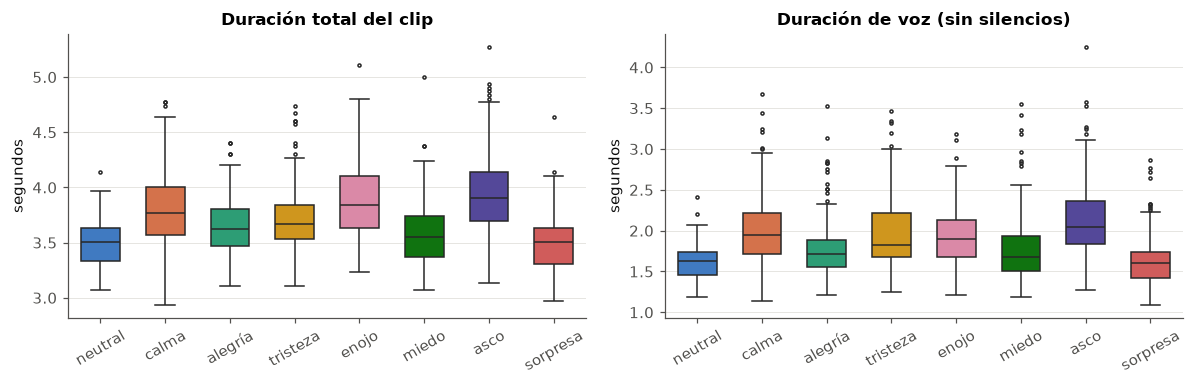

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for ax, col, title in [(axes[0], "dur_total", "Duración total del clip"), (axes[1], "dur_voz", "Duración de voz (sin silencios)")]:
    sns.boxplot(data=data, x="emocion", y=col, hue="emocion", palette=EMO_COLOR, legend=False, dodge=False, ax=ax,
                width=0.6, linewidth=1, fliersize=2, order=ORDER_ES)
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("segundos"); ax.tick_params(axis="x", rotation=30)
fig.tight_layout(); save(fig, "duraciones")
sil = data[["sil_inicio", "sil_final"]].mean()
print("Silencio medio: inicio %.2fs, final %.2fs | fracción de silencio media %.1f%%" % (sil.iloc[0], sil.iloc[1], 100 * (1 - data.dur_voz / data.dur_total).mean()))

## 6. Forma de onda y espectrograma por emoción
Waveplots: actor 04 (mujer) y actor 03 (hombre); espectrogramas: actor 03. En ambos casos, frase *"Kids are talking by the door"*, repetición 1, intensidad fuerte salvo neutral (que solo tiene intensidad normal).

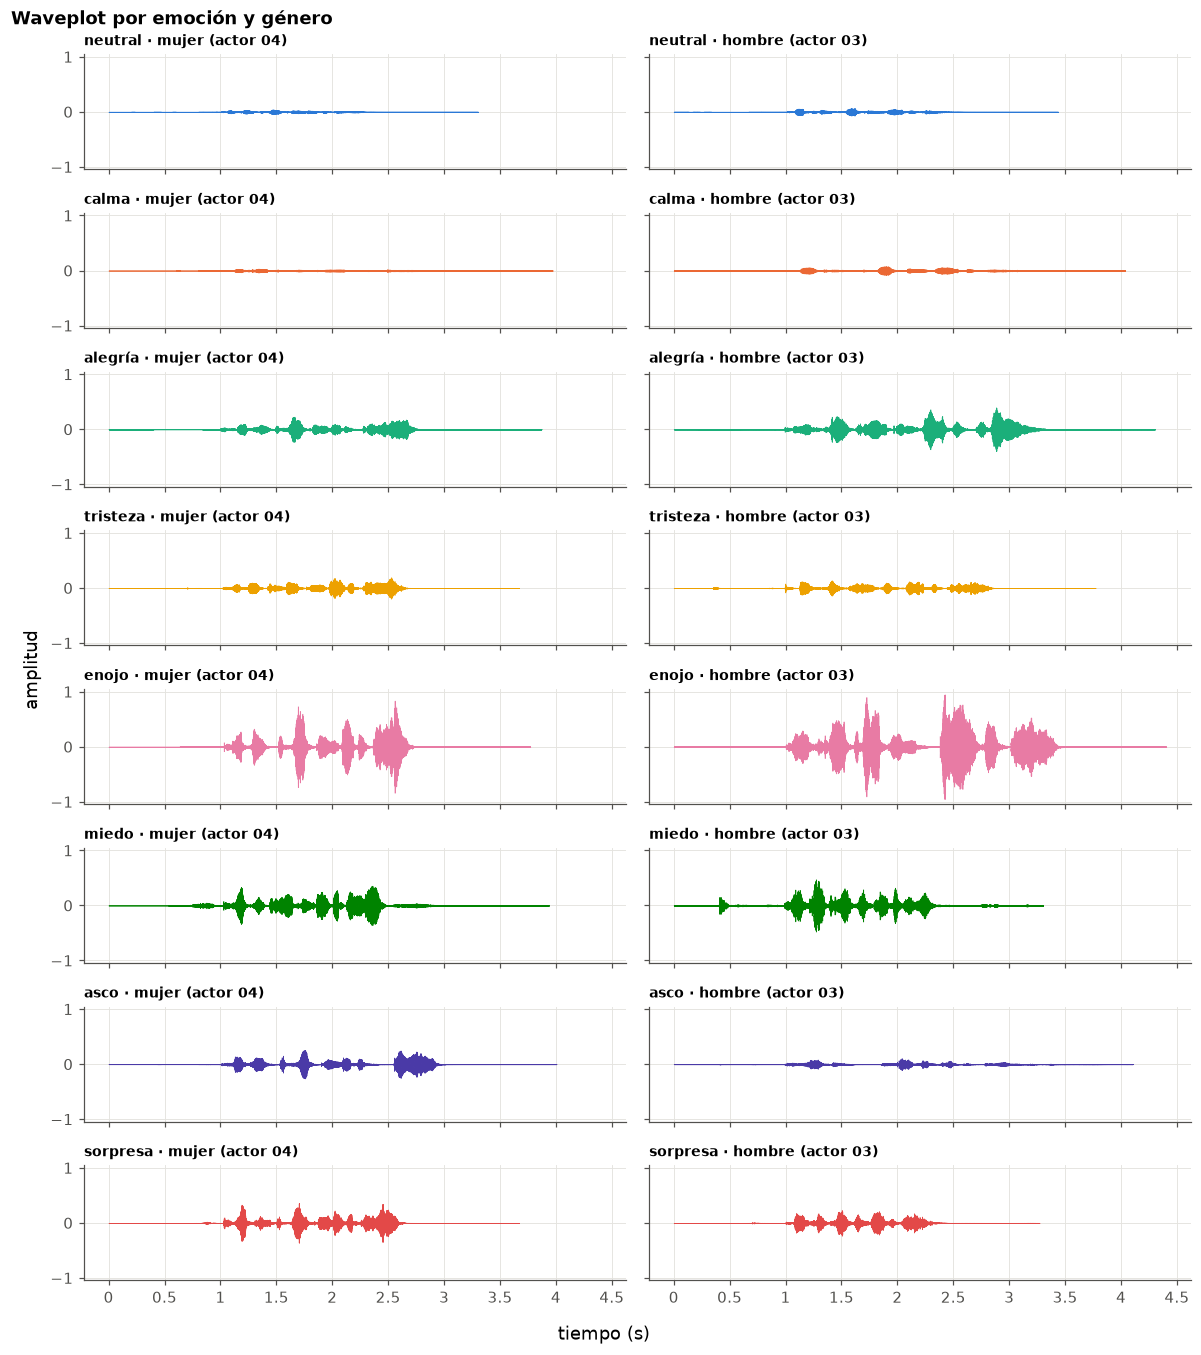

In [9]:
ACTOR_EJ = 3
ej = data[(data.actor == ACTOR_EJ) & (data.statement.str.startswith("Kids")) & (data.repetition == 1) &
          ((data.intensity == "strong") | (data.emotion == "neutral"))].set_index("emocion").loc[ORDER_ES]
# Waveplot por emoción: una mujer (actor 04) y un hombre (actor 03), misma frase y repetición
PAREJA = [("mujer", 4), ("hombre", 3)]
ej2 = data[(data.actor.isin([a for _, a in PAREJA])) & (data.statement.str.startswith("Kids")) & (data.repetition == 1) &
           ((data.intensity == "strong") | (data.emotion == "neutral"))]
fig, axes = plt.subplots(8, 2, figsize=(11, 12.5), sharex=True, sharey=True)
for i, emo in enumerate(ORDER_ES):
    for j, (g, a) in enumerate(PAREJA):
        row = ej2[(ej2.emocion == emo) & (ej2.actor == a)].iloc[0]
        y, _ = librosa.load(row.path, sr=SR)
        ax = axes[i, j]
        librosa.display.waveshow(y, sr=SR, ax=ax, color=EMO_COLOR[emo], linewidth=0.5)
        ax.set_title(f"{emo} · {g} (actor {a:02d})", loc="left", fontsize=9); ax.set_xlabel(""); ax.set_ylabel("")
fig.supxlabel("tiempo (s)"); fig.supylabel("amplitud")
fig.suptitle("Waveplot por emoción y género", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "ondas_por_emocion")

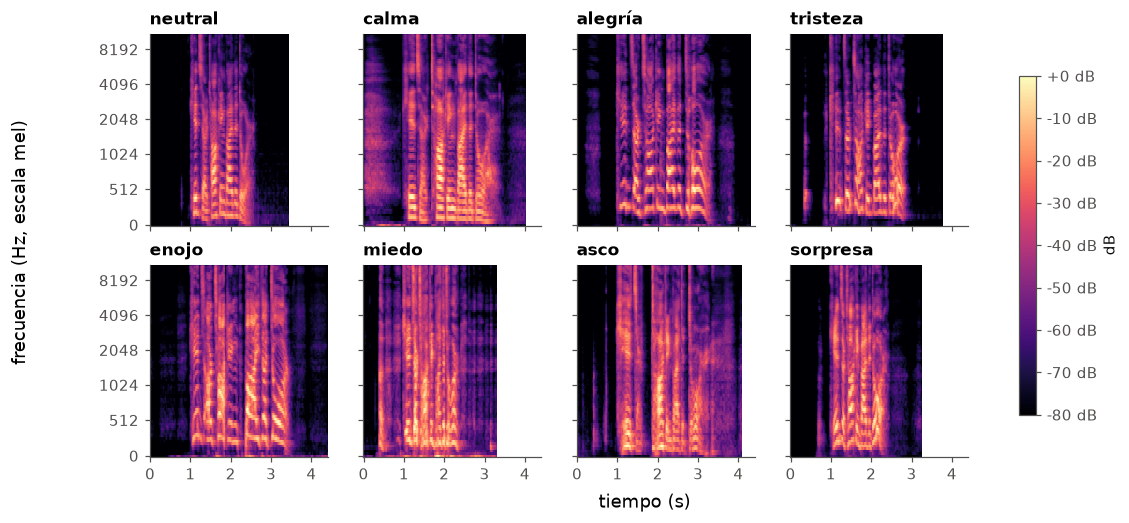

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
for ax, (emo, row) in zip(axes.ravel(), ej.iterrows()):
    y, _ = librosa.load(row.path, sr=SR)
    S = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=SR, n_mels=96), ref=np.max)
    img = librosa.display.specshow(S, sr=SR, x_axis="time", y_axis="mel", ax=ax, cmap="magma", vmin=-80, vmax=0)
    ax.set_title(emo, loc="left"); ax.set_xlabel(""); ax.set_ylabel(""); ax.grid(False)
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(1))
fig.supxlabel("tiempo (s)"); fig.supylabel("frecuencia (Hz, escala mel)")
fig.colorbar(img, ax=axes, format="%+2.0f dB", shrink=0.8, label="dB")
save(fig, "espectrogramas_por_emocion")

neutral     0.0121
calma       0.0080
alegría     0.0254
tristeza    0.0124
enojo       0.0535
miedo       0.0307
asco        0.0172
sorpresa    0.0216
dtype: float32

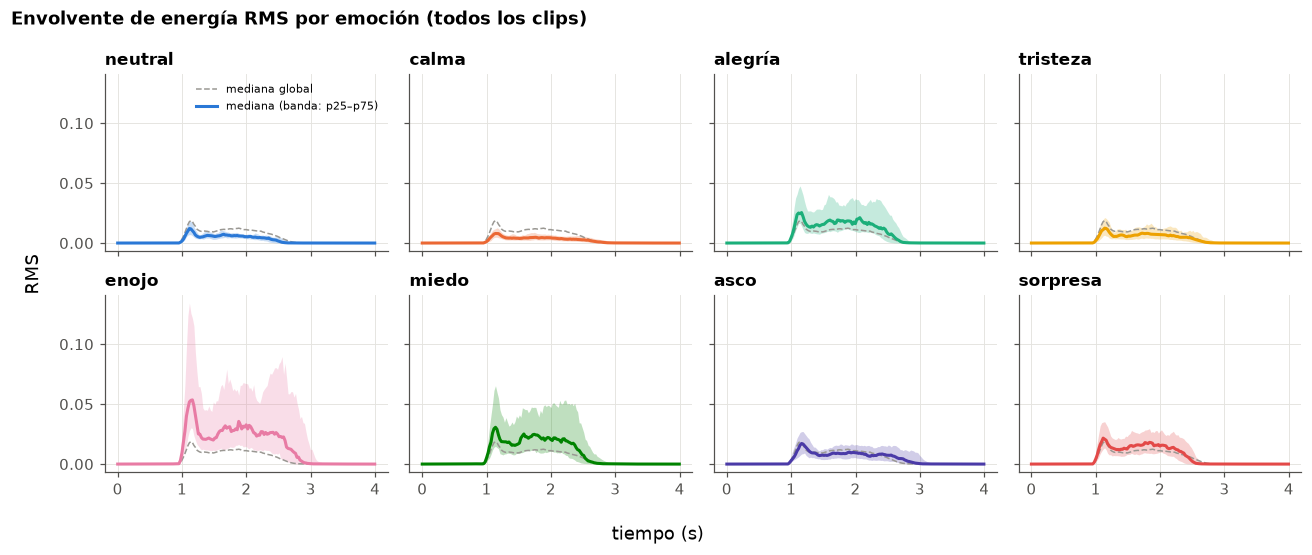

In [11]:
# Envolvente RMS promedio por emoción sobre los 1440 clips (patrón temporal agregado del waveplot)
with ProcessPoolExecutor() as ex:
    ENV = np.stack(list(ex.map(rms_envelope, data["path"], chunksize=16)))
t_env = librosa.frames_to_time(np.arange(ENV.shape[1]), sr=SR, hop_length=HOP_LENGTH)
fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
global_med = np.median(ENV, axis=0)
for ax, emo in zip(axes.ravel(), ORDER_ES):
    E = ENV[(data["emocion"] == emo).values]
    q1, med, q3 = np.percentile(E, [25, 50, 75], axis=0)
    ax.plot(t_env, global_med, color="#9a9893", lw=1, ls="--", label="mediana global")
    ax.fill_between(t_env, q1, q3, color=EMO_COLOR[emo], alpha=0.25, linewidth=0)
    ax.plot(t_env, med, color=EMO_COLOR[emo], lw=2, label="mediana (banda: p25–p75)")
    ax.set_title(emo, loc="left")
axes[0, 0].legend(fontsize=7, loc="upper right")
fig.supxlabel("tiempo (s)"); fig.supylabel("RMS")
fig.suptitle("Envolvente de energía RMS por emoción (todos los clips)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "envolvente_rms_por_emocion")
pico = pd.Series({emo: np.median(ENV[(data["emocion"] == emo).values], axis=0).max() for emo in ORDER_ES})
pico.round(4)

## 7. Descriptores acústicos por emoción

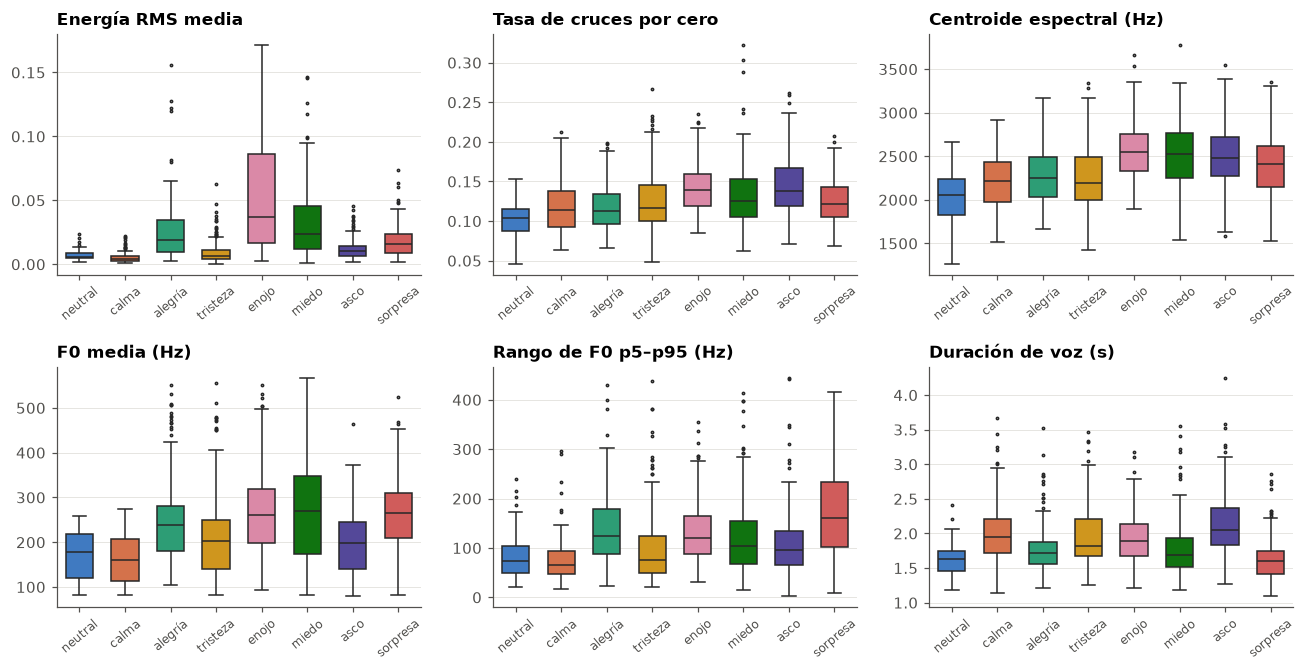

In [12]:
DESC = {"rms_media": "Energía RMS media", "zcr_media": "Tasa de cruces por cero", "centroide_media": "Centroide espectral (Hz)", "f0_media": "F0 media (Hz)", "f0_rango": "Rango de F0 p5–p95 (Hz)", "dur_voz": "Duración de voz (s)"}
fig, axes = plt.subplots(2, 3, figsize=(12, 6.2))
for ax, (col, title) in zip(axes.ravel(), DESC.items()):
    sns.boxplot(data=data, x="emocion", y=col, hue="emocion", palette=EMO_COLOR, legend=False, dodge=False, ax=ax,
                width=0.6, linewidth=1, fliersize=1.5, order=ORDER_ES)
    ax.set_title(title, loc="left"); ax.set_xlabel(""); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=40, labelsize=8)
fig.tight_layout(); save(fig, "descriptores_por_emocion")

In [13]:
# Prueba de Kruskal-Wallis (no paramétrica) por descriptor + tamaño de efecto epsilon^2
rows = []
k = data["emocion"].nunique(); n = len(data)
for col, title in DESC.items():
    groups = [g[col].dropna().values for _, g in data.groupby("emocion", observed=True)]
    H, p = stats.kruskal(*groups)
    rows.append({"descriptor": title, "H": H, "p": p, "eps2": (H - k + 1) / (n - k)})
kw = pd.DataFrame(rows).sort_values("eps2", ascending=False)
kw

,descriptor,H,p,eps2
0,Energía RMS media,645.470365,3.906587e-135,0.445859
5,Duración de voz (s),295.991815,4.341007e-60,0.201810
3,F0 media (Hz),290.940191,5.199655e-59,0.198282
2,Centroide espectral (Hz),248.320062,6.311370e-50,0.168520
4,Rango de F0 p5–p95 (Hz),239.687025,4.331735e-48,0.162491
1,Tasa de cruces por cero,174.405512,2.955007e-34,0.116903


## 8. Efecto del género y de la intensidad

genero
hombre    149.306619
mujer     256.916346
Name: f0_media, dtype: float64
intensidad
fuerte    0.022507
normal    0.008770
Name: rms_media, dtype: float64
MannwhitneyuResult(statistic=np.float64(72909.0), pvalue=np.float64(1.9976700915739802e-120))
MannwhitneyuResult(statistic=np.float64(330439.0), pvalue=np.float64(5.63853104306601e-49))


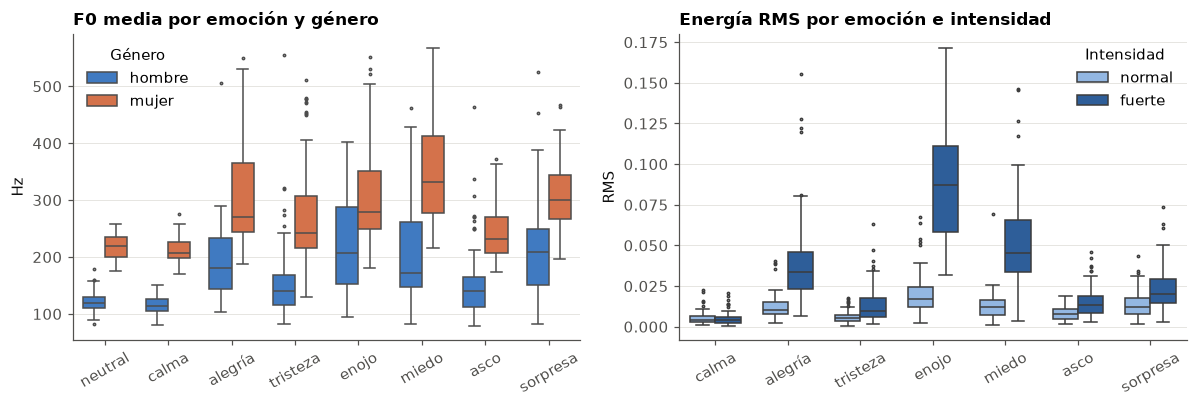

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.boxplot(data=data, x="emocion", y="f0_media", hue="genero", palette=GENDER_COLOR, ax=axes[0],
            width=0.7, linewidth=1, fliersize=1.5, order=ORDER_ES)
axes[0].set_title("F0 media por emoción y género", loc="left"); axes[0].set_xlabel(""); axes[0].set_ylabel("Hz")
axes[0].tick_params(axis="x", rotation=30); axes[0].legend(title="Género")
sub = data[data.emotion != "neutral"]
sns.boxplot(data=sub, x="emocion", y="rms_media", hue="intensidad", palette=INT_COLOR, ax=axes[1],
            width=0.7, linewidth=1, fliersize=1.5, order=ORDER_ES[1:], hue_order=["normal", "fuerte"])
axes[1].set_title("Energía RMS por emoción e intensidad", loc="left"); axes[1].set_xlabel(""); axes[1].set_ylabel("RMS")
axes[1].tick_params(axis="x", rotation=30); axes[1].legend(title="Intensidad")
fig.tight_layout(); save(fig, "genero_intensidad")

f0_gen = data.groupby("genero")["f0_media"].median()
rms_int = sub.groupby("intensidad")["rms_media"].median()
u_gen = stats.mannwhitneyu(*[g["f0_media"].dropna() for _, g in data.groupby("genero")])
w_int = stats.mannwhitneyu(*[g["rms_media"] for _, g in sub.groupby("intensidad")])
print(f0_gen, rms_int, u_gen, w_int, sep="\n")

## 9. Valores atípicos por género (regla IQR)
Para cada descriptor (media por clip de ZCR, RMS y MFCC 1–4) se marca como atípico un valor fuera de
[Q1 − 1.5·IQR, Q3 + 1.5·IQR], calculando los cuartiles **dentro de cada género**.

In [15]:
OUT_FEATS = {"zcr_media": "ZCR", "rms_media": "RMS", "mfcc_1": "MFCC1", "mfcc_2": "MFCC2", "mfcc_3": "MFCC3", "mfcc_4": "MFCC4"}

def iqr_mask(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

rows, masks = [], {}
for g in ["mujer", "hombre"]:
    sub = data[data.genero == g]
    print(f"{'Mujeres' if g == 'mujer' else 'Hombres'}:\nn = {len(sub)}")
    for col, name in OUT_FEATS.items():
        m = iqr_mask(sub[col]); masks[(g, name)] = m
        print(f"Descriptor: {name}. Atípicos: {int(m.sum())}")
        rows.append({"genero": g, "descriptor": name, "n": len(sub), "atipicos": int(m.sum()), "pct": 100 * m.mean()})
    print()
atip = pd.DataFrame(rows)
atip_tab = atip.pivot(index="descriptor", columns="genero", values="atipicos").loc[list(OUT_FEATS.values()), ["mujer", "hombre"]]
atip_tab

Mujeres:
n = 720
Descriptor: ZCR. Atípicos: 11
Descriptor: RMS. Atípicos: 75
Descriptor: MFCC1. Atípicos: 0
Descriptor: MFCC2. Atípicos: 13
Descriptor: MFCC3. Atípicos: 12
Descriptor: MFCC4. Atípicos: 9

Hombres:
n = 720
Descriptor: ZCR. Atípicos: 17
Descriptor: RMS. Atípicos: 75
Descriptor: MFCC1. Atípicos: 1
Descriptor: MFCC2. Atípicos: 9
Descriptor: MFCC3. Atípicos: 3
Descriptor: MFCC4. Atípicos: 6



genero,mujer,hombre
descriptor,,
ZCR,11,17
RMS,75,75
MFCC1,0,1
MFCC2,13,9
MFCC3,12,3
MFCC4,9,6


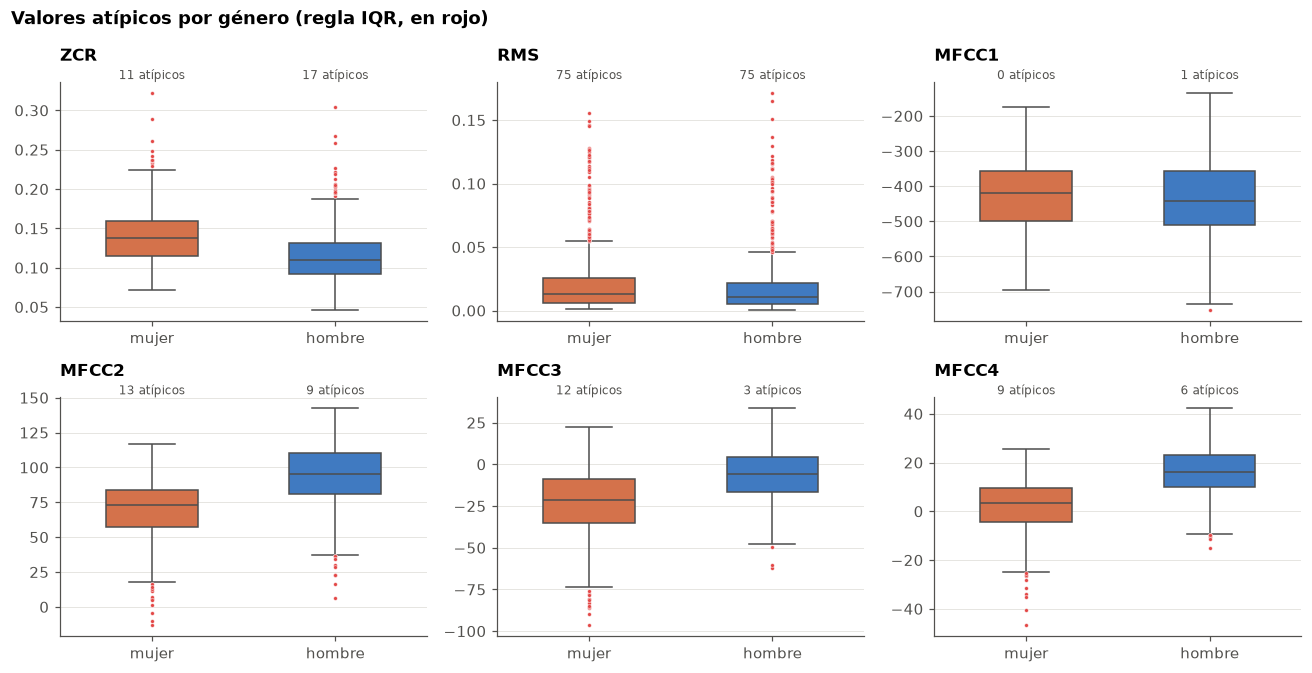

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.2))
for ax, (col, name) in zip(axes.ravel(), OUT_FEATS.items()):
    sns.boxplot(data=data, x="genero", y=col, hue="genero", palette=GENDER_COLOR, legend=False, dodge=False, ax=ax,
                order=["mujer", "hombre"], width=0.5, linewidth=1, fliersize=2.5,
                flierprops={"marker": "o", "markerfacecolor": "#e34948", "markeredgecolor": "white", "markeredgewidth": 0.3})
    for j, g in enumerate(["mujer", "hombre"]):
        k = int(atip.query("genero == @g and descriptor == @name").atipicos.iloc[0])
        ax.text(j, 1.0, f"{k} atípicos", transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=8, color=INK2)
    ax.set_title(name, loc="left", pad=14); ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Valores atípicos por género (regla IQR, en rojo)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "atipicos_genero")

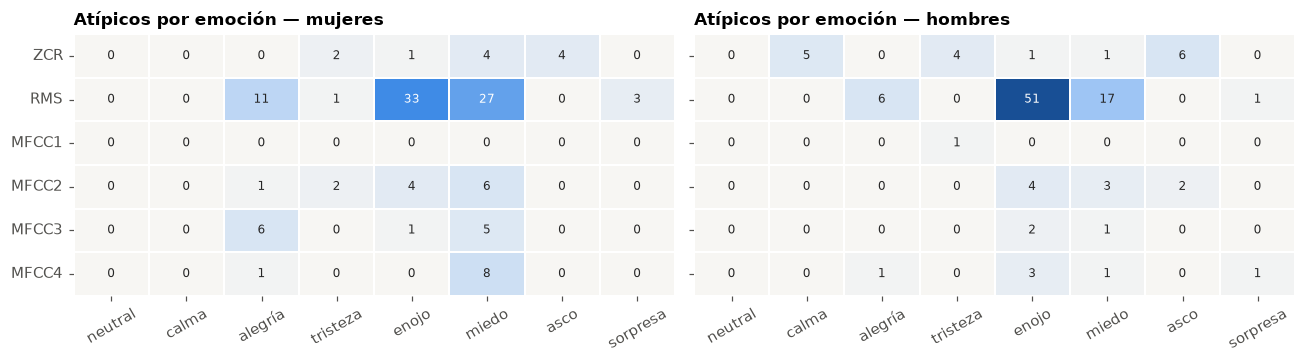

In [17]:
# ¿De qué emociones vienen los atípicos?
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
blues = LinearSegmentedColormap.from_list("seq", ["#f7f6f3", "#9ec5f4", "#3987e5", "#184f95"])
vmax = 0
tabs = {}
for g in ["mujer", "hombre"]:
    sub = data[data.genero == g]
    tabs[g] = pd.DataFrame({name: sub.loc[masks[(g, name)], "emocion"].value_counts().reindex(ORDER_ES, fill_value=0)
                            for name in OUT_FEATS.values()}).T
    vmax = max(vmax, tabs[g].values.max())
for ax, g in zip(axes, ["mujer", "hombre"]):
    sns.heatmap(tabs[g], annot=True, fmt="d", cmap=blues, vmin=0, vmax=vmax, cbar=False, ax=ax,
                linewidths=1, linecolor="white", annot_kws={"size": 8})
    ax.set_title(f"Atípicos por emoción — {g}es" if g == "mujer" else "Atípicos por emoción — hombres", loc="left")
    ax.set_xlabel(""); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=30)
fig.tight_layout(); save(fig, "atipicos_por_emocion")

## 10. Patrones por emoción y género (gráficos de radar)
Media de cada descriptor por emoción, normalizada con Min-Max **entre emociones dentro de cada género**
(0 = la emoción con el valor más bajo, 1 = la más alta).

Mujeres:


Hombres:


mujeres                                               hombres        \
             ZCR   RMS MFCC1 MFCC2 MFCC3 MFCC4 Centroide    F0     ZCR   RMS   
emocion                                                                        
neutral     0.00  0.03  0.17  1.00  0.80  0.96      0.00  0.04    0.00  0.04   
calma       0.28  0.00  0.00  0.74  1.00  1.00      0.35  0.00    0.45  0.00   
alegría     0.41  0.59  0.80  0.43  0.00  0.45      0.52  0.70    0.28  0.30   
tristeza    0.56  0.14  0.24  0.59  0.69  0.73      0.46  0.45    0.52  0.06   
enojo       0.88  1.00  1.00  0.26  0.26  0.34      0.93  0.70    0.92  1.00   
miedo       0.81  0.80  0.85  0.00  0.20  0.00      1.00  1.00    0.55  0.40   
asco        1.00  0.19  0.44  0.57  0.67  0.55      0.84  0.21    1.00  0.10   
sorpresa    0.59  0.33  0.71  0.61  0.49  0.24      0.71  0.70    0.42  0.23   

                                                  
         MFCC1 MFCC2 MFCC3 MFCC4 Centroide    F0  
emocion                                           
neutral   0.19  1.00  0.73  0.90      0.00  0.07  
calma     0.00  0.70  1.00  1.00      0.28  0.00  
alegría   0.58  0.47  0.26  0.08      0.40  0.72  
tristeza  0.14  0.58  0.72  0.79      0.33  0.35  
enojo     1.00  0.00  0.00  0.00      1.00  1.00  
miedo     0.60  0.00  0.37  0.09      0.79  0.84  
asco      0.34  0.29  0.75  0.51      0.86  0.35  
sorpresa  0.56  0.40  0.50  0.17      0.58  0.89

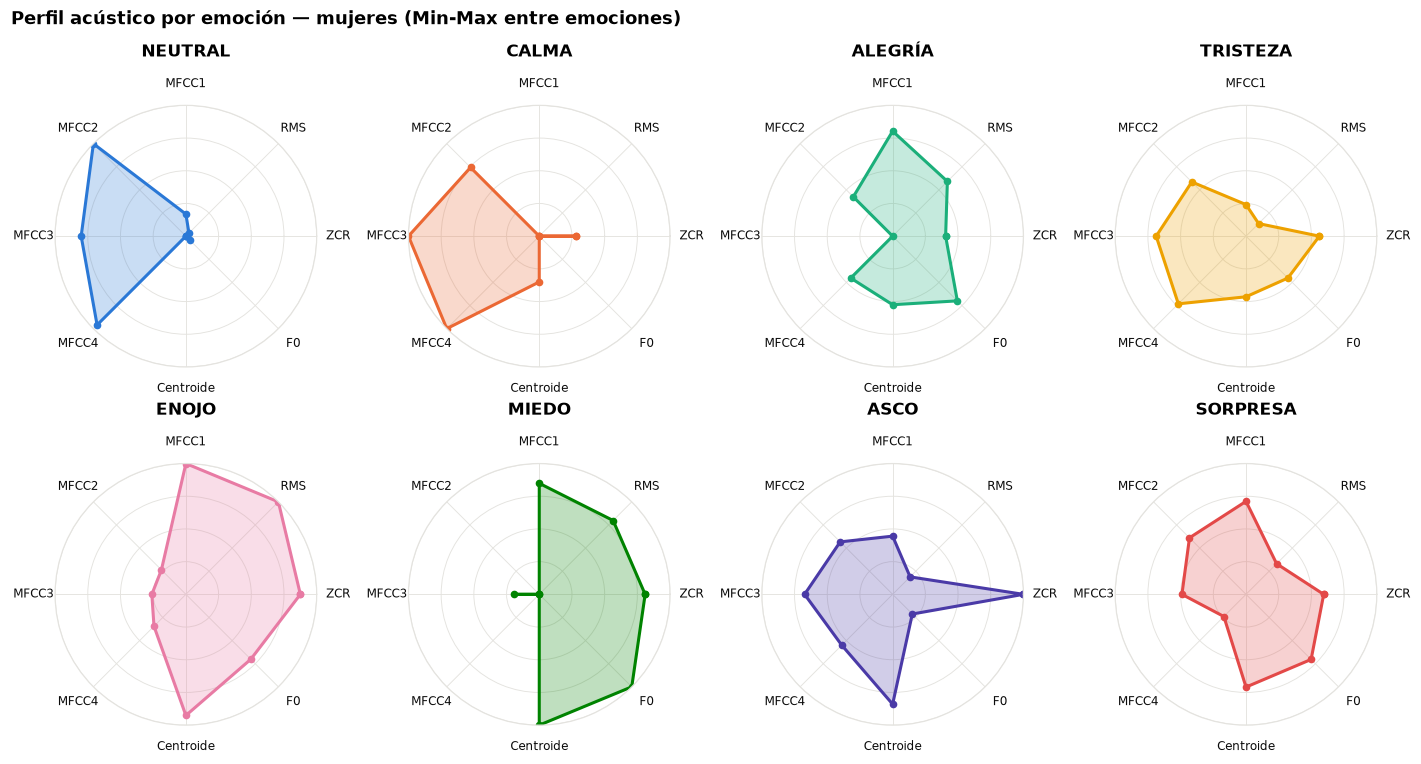

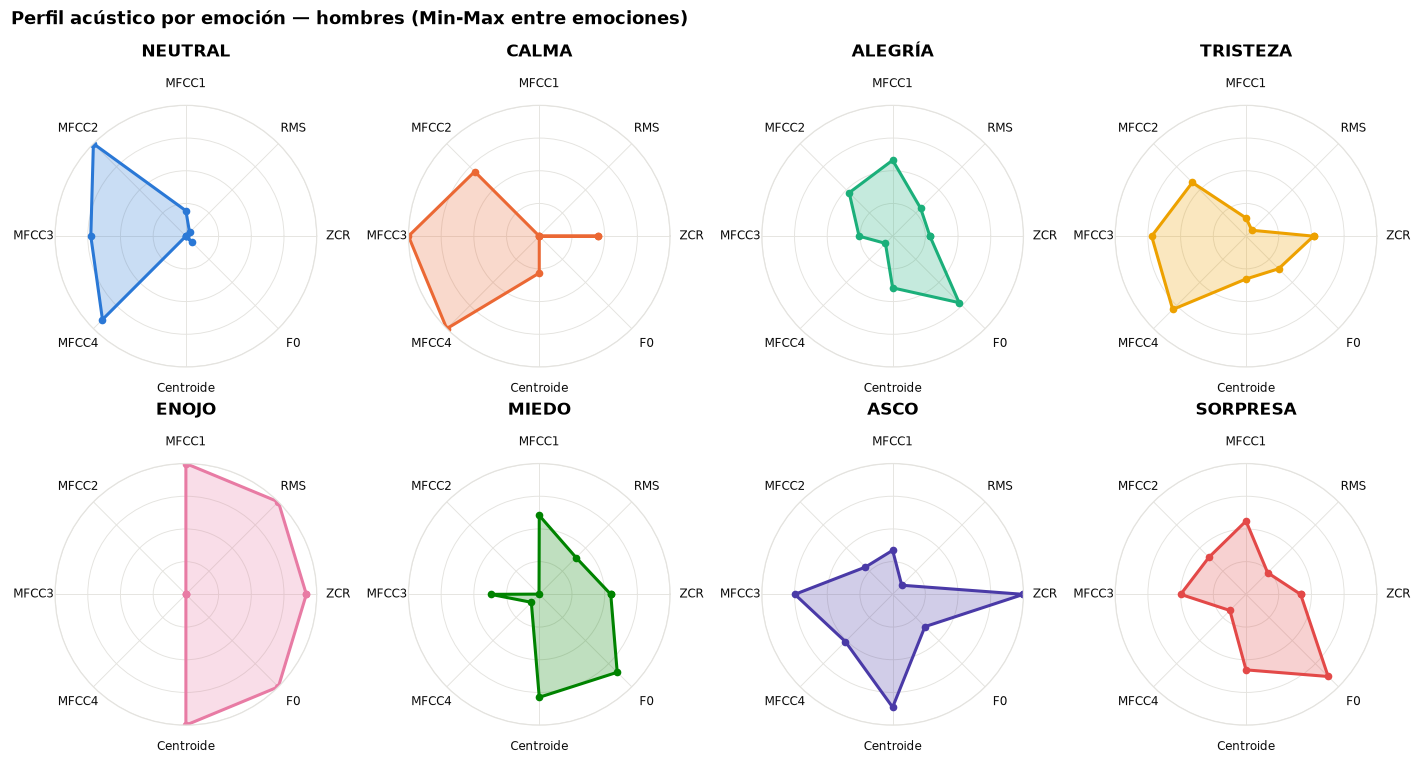

In [18]:
from matplotlib.colors import LinearSegmentedColormap
RADAR_FEATS = {"zcr_media": "ZCR", "rms_media": "RMS", "mfcc_1": "MFCC1", "mfcc_2": "MFCC2", "mfcc_3": "MFCC3",
               "mfcc_4": "MFCC4", "centroide_media": "Centroide", "f0_media": "F0"}

def radar_plot(sub, titulo, nombre):
    means = sub.groupby("emocion", observed=True)[list(RADAR_FEATS)].mean().loc[ORDER_ES].rename(columns=RADAR_FEATS)
    norm = pd.DataFrame(MinMaxScaler().fit_transform(means), index=means.index, columns=means.columns)
    angles = np.append(np.linspace(0, 2 * np.pi, len(norm.columns), endpoint=False), 0)
    fig, axs = plt.subplots(2, 4, figsize=(13, 7), subplot_kw={"polar": True})
    for ax, (emo, row) in zip(axs.ravel(), norm.iterrows()):
        vals = np.append(row.values, row.values[0])
        ax.plot(angles, vals, "o-", color=EMO_COLOR[emo], lw=2, ms=4)
        ax.fill(angles, vals, color=EMO_COLOR[emo], alpha=0.25)
        ax.set_xticks(angles[:-1]); ax.set_xticklabels(norm.columns, fontsize=8, color=INK)
        ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75, 1]); ax.set_yticklabels([], fontsize=6)
        ax.grid(color=GRID); ax.spines["polar"].set_color(GRID)
        ax.set_title(emo.upper(), fontweight="bold", pad=14)
    fig.suptitle(titulo, x=0.01, ha="left", fontweight="bold")
    fig.tight_layout(); save(fig, nombre)
    return norm

print("Mujeres:")
radar_m = radar_plot(data[data.genero == "mujer"], "Perfil acústico por emoción — mujeres (Min-Max entre emociones)", "radar_mujeres")
print("Hombres:")
radar_h = radar_plot(data[data.genero == "hombre"], "Perfil acústico por emoción — hombres (Min-Max entre emociones)", "radar_hombres")
pd.concat({"mujeres": radar_m, "hombres": radar_h}, axis=1).round(2)

## 11. MFCC medios por emoción

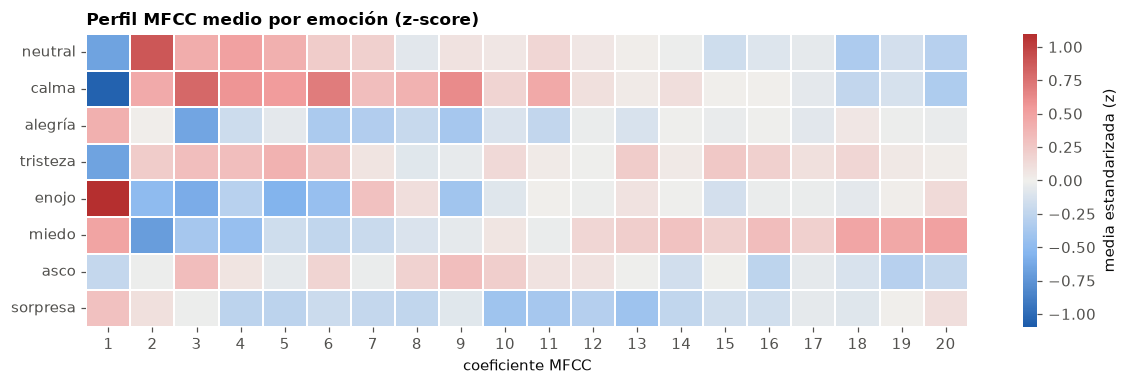

In [19]:
mfcc_cols = [f"mfcc_{i}" for i in range(1, 21)]
z = data[mfcc_cols].apply(lambda c: (c - c.mean()) / c.std())
mfcc_emo = z.groupby(data["emocion"], observed=True).mean().loc[ORDER_ES]
fig, ax = plt.subplots(figsize=(11, 3.6))
lim = np.abs(mfcc_emo.values).max()
from matplotlib.colors import LinearSegmentedColormap
div = LinearSegmentedColormap.from_list("div", ["#1c5cab", "#86b6ef", "#f0efec", "#f19a9a", "#b52f2f"])
sns.heatmap(mfcc_emo, cmap=div, center=0, vmin=-lim, vmax=lim, ax=ax, linewidths=1, linecolor="white",
            cbar_kws={"label": "media estandarizada (z)"}, xticklabels=[str(i) for i in range(1, 21)])
ax.set_xlabel("coeficiente MFCC"); ax.set_ylabel(""); ax.set_title("Perfil MFCC medio por emoción (z-score)", loc="left")
fig.tight_layout(); save(fig, "mfcc_por_emocion")

## 12. Correlación entre descriptores

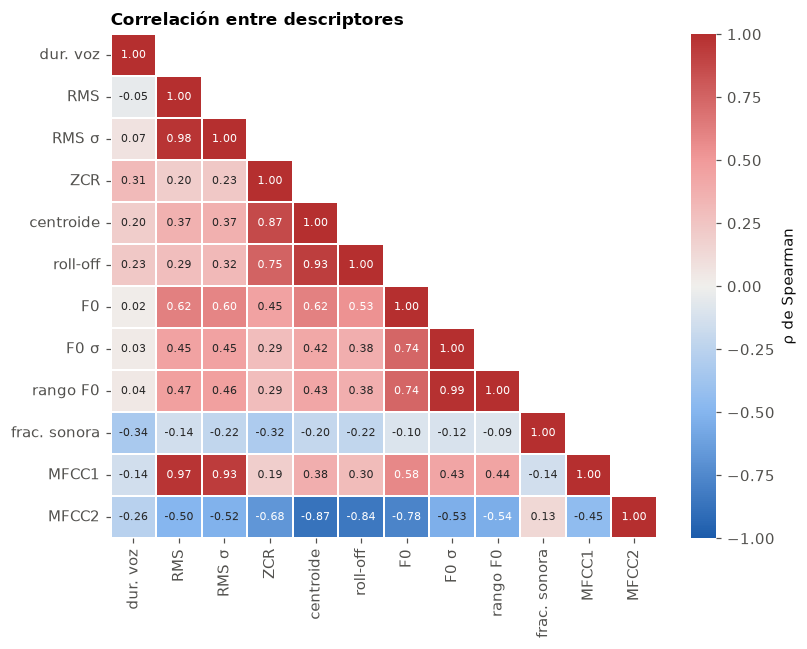

In [20]:
corr_cols = ["dur_voz", "rms_media", "rms_std", "zcr_media", "centroide_media", "rolloff_media", "f0_media", "f0_std", "f0_rango", "frac_sonora", "mfcc_1", "mfcc_2"]
labels = ["dur. voz", "RMS", "RMS σ", "ZCR", "centroide", "roll-off", "F0", "F0 σ", "rango F0", "frac. sonora", "MFCC1", "MFCC2"]
C = data[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7.5, 6))
mask = np.triu(np.ones_like(C, dtype=bool), 1)
sns.heatmap(C, mask=mask, cmap=div, center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=1, linecolor="white", xticklabels=labels, yticklabels=labels, ax=ax, cbar_kws={"label": "ρ de Spearman"})
ax.set_title("Correlación entre descriptores", loc="left"); ax.grid(False)
fig.tight_layout(); save(fig, "correlacion_descriptores")

## 13. Proyección en baja dimensión
PCA y t-SNE sobre los 33 descriptores estandarizados. Se muestran como *small multiples* (cada emoción resaltada sobre el resto en gris), porque 8 colores superpuestos en un scatter no son distinguibles.

Componentes para 90% de varianza: 15


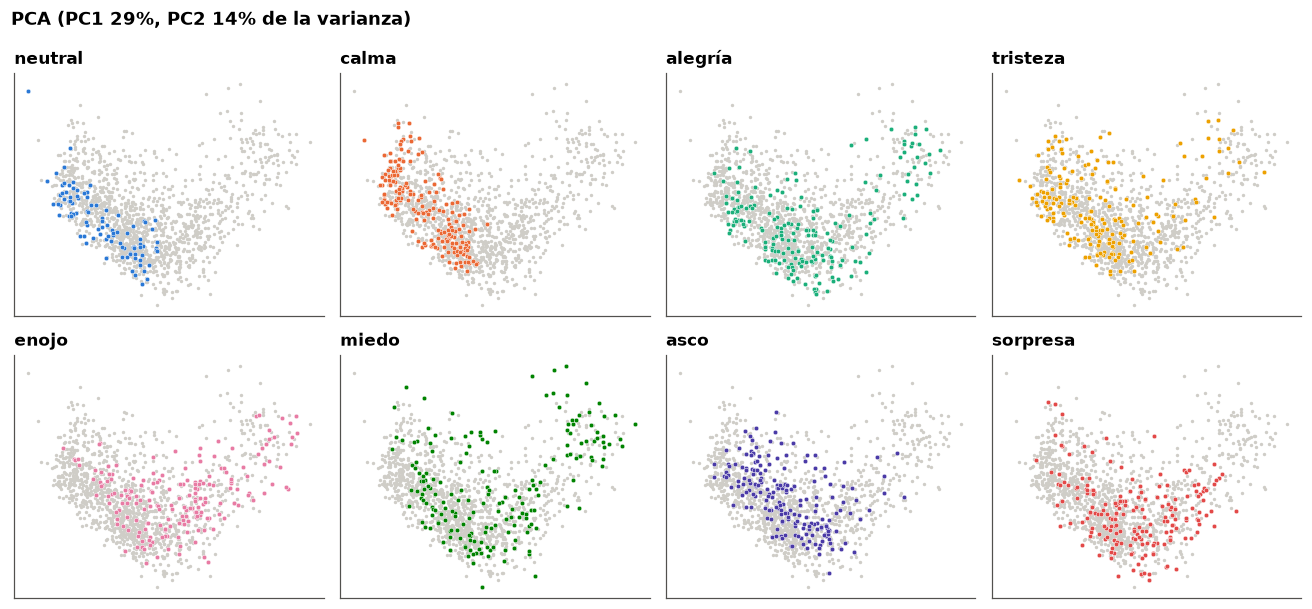

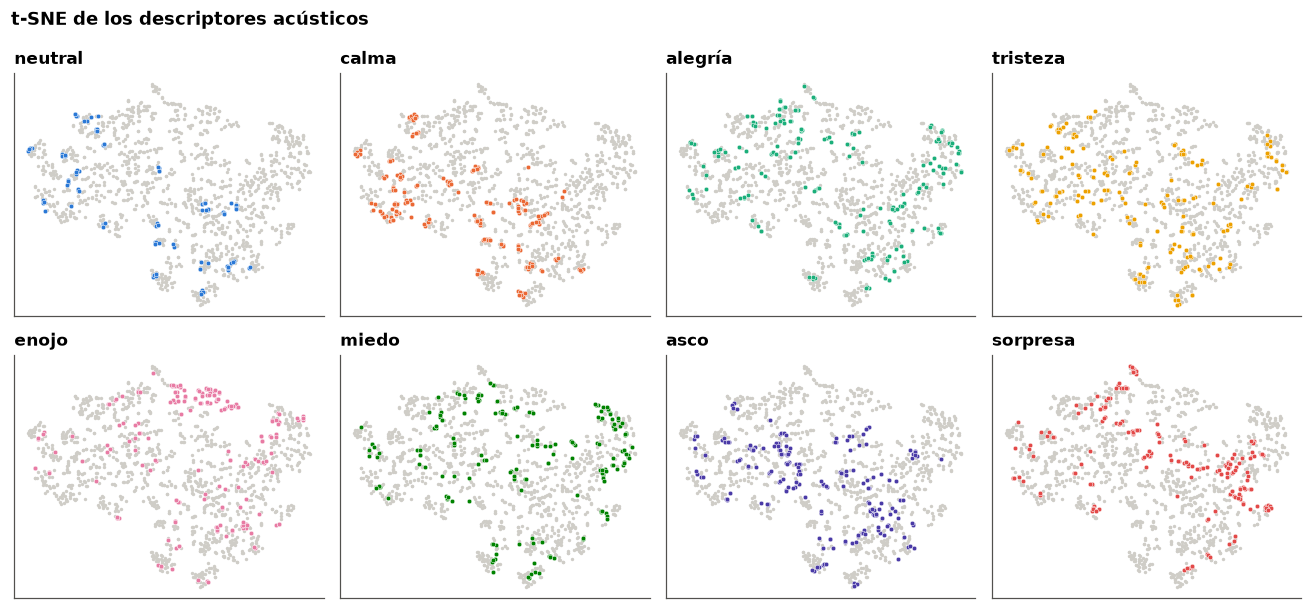

In [21]:
feat_cols = [c for c in feat.columns if c not in ("dur_total", "sil_inicio", "sil_final")]
X = StandardScaler().fit_transform(data[feat_cols].fillna(data[feat_cols].median()))
pca = PCA().fit(X)
P = pca.transform(X)[:, :2]
T = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(X)
var_pc = pca.explained_variance_ratio_
n_pc_90 = int(np.searchsorted(np.cumsum(var_pc), 0.90) + 1)

def small_multiples(E, name, title):
    fig, axes = plt.subplots(2, 4, figsize=(12, 5.6), sharex=True, sharey=True)
    for ax, emo in zip(axes.ravel(), ORDER_ES):
        m = (data["emocion"] == emo).values
        ax.scatter(E[~m, 0], E[~m, 1], s=5, color="#cfcdc7", linewidths=0)
        ax.scatter(E[m, 0], E[m, 1], s=9, color=EMO_COLOR[emo], edgecolor="white", linewidths=0.3)
        ax.set_title(emo, loc="left"); ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title, x=0.01, ha="left", fontweight="bold")
    fig.tight_layout(); save(fig, name)

small_multiples(P, "pca_emociones", f"PCA (PC1 {var_pc[0]:.0%}, PC2 {var_pc[1]:.0%} de la varianza)")
small_multiples(T, "tsne_emociones", "t-SNE de los descriptores acústicos")
print("Componentes para 90% de varianza:", n_pc_90)

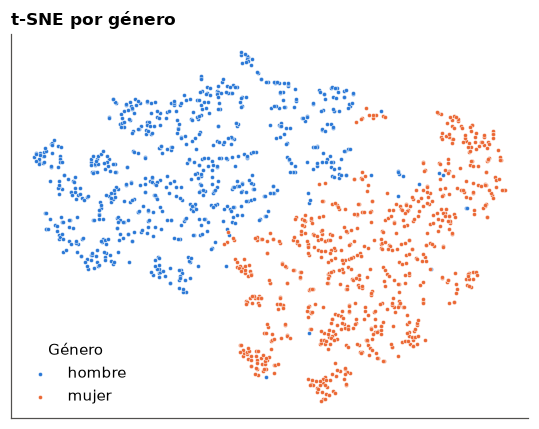

In [22]:
# t-SNE coloreado por género: ¿la estructura dominante es el hablante?
fig, ax = plt.subplots(figsize=(5, 4))
for g, c in GENDER_COLOR.items():
    m = (data["genero"] == g).values
    ax.scatter(T[m, 0], T[m, 1], s=7, color=c, label=g, edgecolor="white", linewidths=0.3)
ax.set_xticks([]); ax.set_yticks([]); ax.legend(title="Género"); ax.set_title("t-SNE por género", loc="left")
fig.tight_layout(); save(fig, "tsne_genero")

## 14. Resumen y exportación de cifras para LaTeX

In [23]:
emo_rms = data.groupby("emocion", observed=True)["rms_media"].median()
emo_f0 = data.groupby("emocion", observed=True)["f0_media"].median()
emo_dur = data.groupby("emocion", observed=True)["dur_voz"].median()
res = {
    "nClips": len(data), "nActores": data.actor.nunique(), "nEmociones": data.emotion.nunique(),
    "nClipsNeutral": int((data.emotion == "neutral").sum()), "nClipsOtras": int((data.emotion == "calm").sum()),
    "nEstereo": int((data.channels == 2).sum()), "tamanoMB": calidad["tamano_total_mb"],
    "durMedia": data.dur_total.mean(), "durMin": data.dur_total.min(), "durMax": data.dur_total.max(),
    "durVozMedia": data.dur_voz.mean(), "silInicio": data.sil_inicio.mean(), "silFinal": data.sil_final.mean(),
    "fracSilencio": 100 * (1 - data.dur_voz / data.dur_total).mean(),
    "foHombre": f0_gen["hombre"], "foMujer": f0_gen["mujer"],
    "rmsNormal": rms_int["normal"], "rmsFuerte": rms_int["fuerte"], "rmsRatio": rms_int["fuerte"] / rms_int["normal"],
    "emoMaxRMS": emo_rms.idxmax(), "emoMinRMS": emo_rms.idxmin(), "rmsMaxVal": emo_rms.max(), "rmsMinVal": emo_rms.min(),
    "emoMaxFo": emo_f0.idxmax(), "emoMinFo": emo_f0.idxmin(), "foMaxVal": emo_f0.max(), "foMinVal": emo_f0.min(),
    "emoMaxDur": emo_dur.idxmax(), "emoMinDur": emo_dur.idxmin(),
    "pcUno": 100 * var_pc[0], "pcDos": 100 * var_pc[1], "nPCNoventa": n_pc_90, "nDescriptores": len(feat_cols),
    "frameLen": FRAME_LENGTH, "hopLen": HOP_LENGTH, "ventanaMs": 1000 * FRAME_LENGTH / SR, "saltoMs": 1000 * HOP_LENGTH / SR,
    "nMujer": int((data.genero == "mujer").sum()), "nHombre": int((data.genero == "hombre").sum()),
    "atipTotalMujer": int(atip.query("genero == 'mujer'").atipicos.sum()), "atipTotalHombre": int(atip.query("genero == 'hombre'").atipicos.sum()),
    "atipMaxDesc": atip.groupby("descriptor").atipicos.sum().idxmax(),
    "kwTop": kw.iloc[0]["descriptor"], "kwTopEps": kw.iloc[0]["eps2"], "kwLow": kw.iloc[-1]["descriptor"], "kwLowEps": kw.iloc[-1]["eps2"],
}
(DATA / "resultados_eda.json").write_text(json.dumps({k: (v.item() if hasattr(v, "item") else v) for k, v in res.items()}, indent=2, ensure_ascii=False))

def fmt(v):
    if isinstance(v, (int, np.integer)): return f"{v}"
    if isinstance(v, (float, np.floating)): return f"{v:.3f}" if abs(v) < 1 else f"{v:.1f}"
    return str(v)
lines = ["% Archivo generado automáticamente por notebooks/01_eda.ipynb -- no editar a mano"]
lines += [f"\\newcommand{{\\{k}}}{{{fmt(v)}}}" for k, v in res.items()]
# Tabla Kruskal-Wallis
lines += ["\\newcommand{\\tablaKruskal}{%"]
for _, r in kw.iterrows():
    p = "$<10^{-10}$" if r.p < 1e-10 else f"{r.p:.2e}"
    lines.append(f"{r.descriptor} & {r.H:.1f} & {p} & {r.eps2:.3f} \\\\")
lines += ["}"]
# Tabla de medianas por emoción
med = data.groupby("emocion", observed=True)[["dur_voz", "rms_media", "zcr_media", "centroide_media", "f0_media"]].median().loc[ORDER_ES]
lines += ["\\newcommand{\\tablaMedianas}{%"]
for emo, r in med.iterrows():
    lines.append(f"{emo} & {r.dur_voz:.2f} & {r.rms_media:.3f} & {r.zcr_media:.3f} & {r.centroide_media:.0f} & {r.f0_media:.0f} \\\\")
lines += ["}"]
lines += ["\\newcommand{\\tablaAtipicos}{%"]
for name, r in atip_tab.iterrows():
    pm = atip.query("genero == 'mujer' and descriptor == @name").pct.iloc[0]
    ph = atip.query("genero == 'hombre' and descriptor == @name").pct.iloc[0]
    lines.append(f"{name} & {r.mujer} & {pm:.1f}\\,\\% & {r.hombre} & {ph:.1f}\\,\\% \\\\")
lines += ["}"]
lines += ["\\newcommand{\\tablaFrameHop}{%"]
for _, r in tabla_fh.iterrows():
    lines.append(f"{int(r.frame_length)} & {int(r.hop_length)} & {r['ventana (ms)']:.1f} & {r['salto (ms)']:.1f} & {int(r['cuadros en 2.5 s'])} \\\\")
lines += ["}"]
(ROOT / "latex" / "resultados_eda.tex").write_text("\n".join(lines) + "\n", encoding="utf-8")
print((ROOT / "latex" / "resultados_eda.tex").read_text())

% Archivo generado automáticamente por notebooks/01_eda.ipynb -- no editar a mano
\newcommand{\nClips}{1440}
\newcommand{\nActores}{24}
\newcommand{\nEmociones}{8}
\newcommand{\nClipsNeutral}{96}
\newcommand{\nClipsOtras}{192}
\newcommand{\nEstereo}{5}
\newcommand{\tamanoMB}{590.3}
\newcommand{\durMedia}{3.7}
\newcommand{\durMin}{2.9}
\newcommand{\durMax}{5.3}
\newcommand{\durVozMedia}{1.9}
\newcommand{\silInicio}{0.937}
\newcommand{\silFinal}{0.893}
\newcommand{\fracSilencio}{49.8}
\newcommand{\foHombre}{149.3}
\newcommand{\foMujer}{256.9}
\newcommand{\rmsNormal}{0.009}
\newcommand{\rmsFuerte}{0.023}
\newcommand{\rmsRatio}{2.6}
\newcommand{\emoMaxRMS}{enojo}
\newcommand{\emoMinRMS}{calma}
\newcommand{\rmsMaxVal}{0.037}
\newcommand{\rmsMinVal}{0.004}
\newcommand{\emoMaxFo}{miedo}
\newcommand{\emoMinFo}{calma}
\newcommand{\foMaxVal}{270.7}
\newcommand{\foMinVal}{160.5}
\newcommand{\emoMaxDur}{asco}
\newcommand{\emoMinDur}{sorpresa}
\newcommand{\pcUno}{29.2}
\newcommand{\pcDos}{13.5}
\ne